# Retrieval Ablation — Essays Test Set

Full end-to-end pipeline: prediction on Essays test set + RAG metric evaluation,
controlled by a single `rag_mode` parameter.

## RAG modes

| `rag_mode` | Strategy | Index |
|---|---|---|
| `rawpost` | Raw-post baseline | `data/vector_db/essays_rawpost` ✅ |
| `profile` | Full 30-facet profile embedding | `data/vector_db/essays_profile` ✅ |
| `sliced_dual` | Trait-sliced dual fusion | `data/vector_db/essays_sliced_dual/{trait_code}` ⚠️ |
| `facet_embed` | Dual fusion, γ=0 (dense only) | `data/vector_db/essays_dual` ✅ |
| `hybrid_facet` | Dual fusion + per-trait facet re-rank | `data/vector_db/essays_dual` + `facet_vectors.npy` ✅ |

**⚠️ `sliced_dual`** — run `notebook/gpt/build_sliced_dual_index.ipynb` first.

## Pipeline steps
1. Config + imports
2. Profile test set (label-blind)
3. Install mode-specific retriever adapter
4. Sanity check
5. Run `predict()` → save predictions
6. Evaluate predictions (accuracy / F1)
7. Compute RAG metrics (MMR@k, HR@k) on test queries
8. Save RAG metrics → `result/rag_ablation/{rag_mode}/`
9. Plots + LaTeX rows
10. Cleanup (restore retriever)

## Configuration

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
for _ in range(4):
    if (project_root / "ptd_model").exists():
        break
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ── RAG mode ─────────────────────────────────────────────────────────────────
# Options: "rawpost" | "profile" | "sliced_dual" | "facet_embed" | "hybrid_facet"
rag_mode = "hybrid_facet"   # ← change this

# ── prediction settings ───────────────────────────────────────────────────────
model_name     = "gpt-4o-mini"
prompt_mode    = "reasoned_rag_def_oneshot"
max_new_tokens = 512
temperature    = 0.0
top_k          = 5

# ── RAG metric k values ───────────────────────────────────────────────────────
K_VALUES = [3, 5]

# ── paths ─────────────────────────────────────────────────────────────────────
test_csv        = str(project_root / "data/split/essays/test.csv")
test_profile_db = str(project_root / "data/profile_db/essays_test")
profiler_model  = "gpt-4o-mini"

res_dir         = str(project_root / "result")
log_dir         = str(project_root / "log")
rag_metrics_dir = str(project_root / f"result/rag_ablation/{rag_mode}")

# ── index paths (do not rename existing folders) ─────────────────────────────
INDEX_DIRS = {
    "rawpost":      str(project_root / "data/vector_db/essays_rawpost"),
    "profile":      str(project_root / "data/vector_db/essays_profile"),
    "sliced_dual":  str(project_root / "data/vector_db/essays_sliced_dual"),
    "facet_embed":  str(project_root / "data/vector_db/essays_dual"),
    "hybrid_facet": str(project_root / "data/vector_db/essays_dual"),
}
vector_db_dir = INDEX_DIRS[rag_mode]

TRAITS = {
    "cOPN": "Openness to Experience",
    "cCON": "Conscientiousness",
    "cEXT": "Extraversion",
    "cAGR": "Agreeableness",
    "cNEU": "Neuroticism",
}
TRAIT_NAMES = list(TRAITS.values())
TRAIT_CODES = {v: k for k, v in TRAITS.items()}
TRAIT_SHORT = {
    "cOPN": "Openness",
    "cCON": "Conscientiousness",
    "cEXT": "Extraversion",
    "cAGR": "Agreeableness",
    "cNEU": "Neuroticism",
}

print(f"Project root : {project_root}")
print(f"rag_mode     : {rag_mode}")
print(f"prompt_mode  : {prompt_mode}  |  top_k={top_k}")
print(f"index dir    : {vector_db_dir}")
print(f"rag metrics  : {rag_metrics_dir}")

Project root : F:\std\GR\code\model_x_ocean
rag_mode     : hybrid_facet
prompt_mode  : reasoned_rag_def_oneshot  |  top_k=5
index dir    : F:\std\GR\code\model_x_ocean\data\vector_db\essays_dual
rag metrics  : F:\std\GR\code\model_x_ocean\result\rag_ablation\hybrid_facet


## Imports & path checks

In [2]:
import os, json, time
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rag.faiss_index      import FAISSIndex
from rag.embedder         import _embed_single, get_embedding, get_dual_embedding
from rag.profiler.store   import ProfileStore
from rag.profiler.runner  import build_profiles
from rag.profiler.prompts import FACETS, slice_profile_for_trait
from rag.facet_vector     import (
    facet_vector, facet_cosine, hybrid_score,
    FACET_ORDER, load_facet_matrix,
)
import rag.retriever as _retriever_mod
from rag.retriever import FeatureRAGRetriever

from ptd_model.predict   import predict
from ptd_model.evaluate  import evaluate

def normalize_label(val):
    s = str(val).strip().lower()
    if s in ("1", "1.0"): return "high"
    if s in ("0", "0.0"): return "low"
    return s

# ── path checks ───────────────────────────────────────────────────────────────
test_df = pd.read_csv(test_csv)
print(f"Test split: {len(test_df)} rows")

checks = [
    ("test_csv",        test_csv),
    ("test_profile_db", test_profile_db),
    ("index_dir",       vector_db_dir),
]
for label, p in checks:
    ok = Path(p).exists()
    print(f"  {'OK' if ok else 'MISSING':7s}  {label}: {p}")

if rag_mode == "sliced_dual":
    for tc in TRAITS:
        p = Path(INDEX_DIRS["sliced_dual"]) / tc / "vectors.faiss"
        ok = p.exists()
        print(f"  {'OK' if ok else 'MISSING':7s}  sliced_dual/{tc}/vectors.faiss")
    if not ok:
        print("\n⚠️  Run notebook/gpt/build_sliced_dual_index.ipynb first!")

if rag_mode == "hybrid_facet":
    fp = Path(vector_db_dir) / "facet_vectors.npy"
    print(f"  {'OK' if fp.exists() else 'MISSING':7s}  facet_vectors.npy")

Test split: 247 rows
  OK       test_csv: F:\std\GR\code\model_x_ocean\data\split\essays\test.csv
  OK       test_profile_db: F:\std\GR\code\model_x_ocean\data\profile_db\essays_test
  OK       index_dir: F:\std\GR\code\model_x_ocean\data\vector_db\essays_dual
  OK       facet_vectors.npy


## Step 1 — Profile the test set (label-blind)

Test profiles must be generated **without labels** to avoid leakage.
Skipped if profiles already exist in `data/profile_db/essays_test/`.

In [3]:
test_store_path = Path(test_profile_db) / "profile_store.jsonl"
test_store = ProfileStore(str(test_store_path))
test_store.load()
needed = len(test_df) - sum(
    1 for i in range(len(test_df))
    if test_store.has(f"user_{i}") and test_store.get(f"user_{i}").get("valid")
)
print(f"Test profiles in store: {len(test_store)}; missing: {needed}")

if needed > 0:
    test_store = build_profiles(
        data       = test_df,
        output_dir = test_profile_db,
        model_name = profiler_model,
        log_dir    = str(Path(log_dir) / "profiler_test"),
        use_labels = False,
    )

test_profiles_by_idx = {
    int(e["user_id"].split("_")[1]): e
    for e in test_store.get_all() if e.get("valid")
}
print(f"Test profiles ready: {len(test_profiles_by_idx)}")

Test profiles in store: 247; missing: 0
Test profiles ready: 247


## Step 2 — Mode-specific retriever adapter

Each `rag_mode` gets a custom `FeatureRAGRetriever` subclass that:
- embeds query essays according to the mode's strategy,
- returns the right kind of few-shot evidence to the predictor.

Monkey-patched onto `rag.retriever.FeatureRAGRetriever` so `ptd_model.predict` picks it up.

In [4]:
ALPHA = 0.5  # raw-vs-profile fusion weight (matches build_dual_index.ipynb)

# ── helpers shared by all modes ───────────────────────────────────────────────

def _profile_to_full_text(entry: Dict) -> str:
    facets = entry.get("facets", {})
    ling   = entry.get("linguistic", {})
    lines  = ["[FACETS]"]
    for code, name, *_ in FACETS:
        f = facets.get(code, {})
        lines.append(f"{code} {name:<18}| {f.get('signal','')} | {f.get('evidence','')}")
    lines.append("\n[LINGUISTIC]")
    for k, v in ling.items():
        lines.append(f"{k}: {v}")
    return "\n".join(lines)


# ── mode-specific retriever classes ──────────────────────────────────────────

class RawpostRetriever(FeatureRAGRetriever):
    """Embeds raw text; returns trait-sliced profile evidence from index."""
    def __init__(self, db_dir, test_profiles, text_to_idx):
        super().__init__(db_dir=db_dir)
        self._test_profiles = test_profiles
        self._text_to_idx   = text_to_idx

    def retrieve(self, posts, trait, top_k=5, **kwargs):
        return super().retrieve(posts=posts, trait=trait, top_k=top_k)


class ProfileRetriever(FeatureRAGRetriever):
    """Embeds full 30-facet profile text as query."""
    def __init__(self, db_dir, test_profiles, text_to_idx):
        super().__init__(db_dir=db_dir)
        self._test_profiles = test_profiles
        self._text_to_idx   = text_to_idx

    def _embed_query(self, text, profile_text=None):
        idx     = self._text_to_idx.get(str(text))
        entry   = self._test_profiles.get(idx) if idx is not None else None
        prof    = _profile_to_full_text(entry) if (entry and entry.get("valid")) else str(text)
        return super()._embed_query(prof)


class SlicedDualRetriever(FeatureRAGRetriever):
    """Per-trait: fuses raw + trait-sliced profile text as query."""
    def __init__(self, db_dir, test_profiles, text_to_idx):
        # db_dir is the base sliced_dual dir; index loaded per-trait below
        super().__init__(db_dir=str(Path(db_dir) / "cOPN"))   # placeholder init
        self._base_dir      = db_dir
        self._test_profiles = test_profiles
        self._text_to_idx   = text_to_idx
        self._trait_indexes: Dict[str, FAISSIndex] = {}

    def _get_trait_index(self, trait_code: str) -> FAISSIndex:
        if trait_code not in self._trait_indexes:
            idx_dir  = Path(self._base_dir) / trait_code
            fi = FAISSIndex(dimension=0)
            fi.load(str(idx_dir / "vectors.faiss"), str(idx_dir / "vectors_meta.jsonl"))
            self._trait_indexes[trait_code] = fi
        return self._trait_indexes[trait_code]

    def _embed_query_for_trait(self, text: str, trait_code: str) -> np.ndarray:
        idx   = self._text_to_idx.get(str(text))
        entry = self._test_profiles.get(idx) if idx is not None else None
        if entry and entry.get("valid"):
            sliced = slice_profile_for_trait(entry, trait_code)
            prof_text = sliced if sliced.strip() else str(text)
        else:
            prof_text = str(text)
        raw_vec  = np.array(_embed_single(str(text)),     dtype="float32")
        prof_vec = np.array(_embed_single(prof_text),     dtype="float32")
        fused    = ALPHA * raw_vec + (1 - ALPHA) * prof_vec
        norm     = np.linalg.norm(fused)
        return (fused / norm) if norm > 0 else fused

    def retrieve(self, posts, trait, top_k=5, **kwargs):
        trait_code = TRAIT_CODES.get(trait)
        if trait_code is None:
            return super().retrieve(posts=posts, trait=trait, top_k=top_k)
        fi      = self._get_trait_index(trait_code)
        q_emb   = self._embed_query_for_trait(posts, trait_code)
        _, hits = fi.search(q_emb, top_k * 6)
        return [r for r in hits if trait in r.get("trait_labels", {})][:top_k]


class FacetEmbedRetriever(FeatureRAGRetriever):
    """Dual-fused query (raw + full profile), dense-only retrieval (gamma=0)."""
    def __init__(self, db_dir, test_profiles, text_to_idx):
        super().__init__(db_dir=db_dir, use_hybrid=False)
        self._test_profiles = test_profiles
        self._text_to_idx   = text_to_idx

    def _embed_query(self, text, profile_text=None):
        idx   = self._text_to_idx.get(str(text))
        entry = self._test_profiles.get(idx) if idx is not None else None
        if entry and entry.get("valid"):
            prof_text = _profile_to_full_text(entry)
            return get_dual_embedding(str(text), prof_text, alpha=ALPHA)
        return super()._embed_query(str(text))


class HybridFacetRetriever(FeatureRAGRetriever):
    """Dual-fused query + per-trait facet cosine re-ranking (the proposed pipeline)."""
    def __init__(self, db_dir, test_profiles, text_to_idx):
        super().__init__(db_dir=db_dir, use_hybrid=True)
        self._test_profiles = test_profiles
        self._text_to_idx   = text_to_idx

    def _embed_query(self, text, profile_text=None):
        idx   = self._text_to_idx.get(str(text))
        entry = self._test_profiles.get(idx) if idx is not None else None
        if entry and entry.get("valid"):
            prof_text = _profile_to_full_text(entry)
            return get_dual_embedding(str(text), prof_text, alpha=ALPHA)
        return super()._embed_query(str(text))

    def _get_query_facet_vector(self, text: str) -> np.ndarray:
        idx   = self._text_to_idx.get(str(text))
        entry = self._test_profiles.get(idx) if idx is not None else None
        if entry and entry.get("valid"):
            return facet_vector(entry, normalize=True)
        return np.zeros(len(FACET_ORDER), dtype=np.float32)


# ── factory ───────────────────────────────────────────────────────────────────

_RETRIEVER_CLASSES = {
    "rawpost":      RawpostRetriever,
    "profile":      ProfileRetriever,
    "sliced_dual":  SlicedDualRetriever,
    "facet_embed":  FacetEmbedRetriever,
    "hybrid_facet": HybridFacetRetriever,
}

_OriginalRetriever = _retriever_mod.FeatureRAGRetriever
_text_to_idx = {str(t): i for i, t in enumerate(test_df["text"].tolist())}

def _RetrieverFactory(db_dir=None):
    cls = _RETRIEVER_CLASSES[rag_mode]
    return cls(
        db_dir        = db_dir or vector_db_dir,
        test_profiles = test_profiles_by_idx,
        text_to_idx   = _text_to_idx,
    )

_retriever_mod.FeatureRAGRetriever = _RetrieverFactory
print(f"[adapter] {rag_mode} retriever installed.")

[adapter] hybrid_facet retriever installed.


## Step 3 — Sanity check

Renders one few-shot context for the first test essay to confirm the retriever works.

In [5]:
_smoke      = _RetrieverFactory(db_dir=vector_db_dir)
_query_text = test_df.iloc[0]["text"]

for trait_full in TRAIT_NAMES[:2]:   # print first two traits to keep output short
    results = _smoke.retrieve(posts=_query_text, trait=trait_full, top_k=top_k)
    print(f"\n=== {trait_full} ({len(results)} retrieved) ===")
    for i, r in enumerate(results):
        label = r.get("trait_labels", {}).get(trait_full, "?")
        print(f"  [{i+1}] label={label}  keys={list(r.keys())[:5]}")

[retriever] mode='legacy'  dir='F:\\std\\GR\\code\\model_x_ocean\\data\\vector_db\\essays_dual'  hybrid=True
[embedder] Loading embedding model: nomic-ai/nomic-embed-text-v1.5


<All keys matched successfully>


[retriever] Legacy index loaded (1974 vectors).

=== Openness to Experience (5 retrieved) ===
  [1] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [2] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [3] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [4] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [5] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']

=== Conscientiousness (5 retrieved) ===
  [1] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [2] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [3] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [4] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']
  [5] label=?  keys=['user_id', 'posts_raw', 'label', 'profile', 'distance']


## Step 4 — Run prediction

In [6]:
run_id, run_time, prediction_csv = predict(
    text_df        = test_df,
    model_name     = model_name,
    log_dir        = log_dir,
    prompt_mode    = prompt_mode,
    max_new_tokens = max_new_tokens,
    res_dir        = res_dir,
    temperature    = temperature,
    top_k          = top_k,
    vector_db_dir  = vector_db_dir,
)

print(f"\nDone in {run_time:.1f}s")
print(f"Predictions: {prediction_csv}")

[retriever] mode='legacy'  dir='F:\\std\\GR\\code\\model_x_ocean\\data\\vector_db\\essays_dual'  hybrid=True
[predict] RAG retriever ready (top_k=5).
[predict] 247 records | mode=reasoned_rag_def_oneshot | model=gpt-4o-mini
[retriever] Legacy index loaded (1974 vectors).
[retriever] Facet matrix loaded ((1974, 30)).
  [predict] 10/247 done.
  [predict] 20/247 done.
  [predict] 30/247 done.
  [predict] 40/247 done.
  [predict] 50/247 done.
  [predict] 60/247 done.
  [predict] 70/247 done.
  [predict] 80/247 done.
  [predict] 90/247 done.
  [predict] 100/247 done.
  [predict] 110/247 done.
  [predict] 120/247 done.
  [predict] 130/247 done.
  [predict] 140/247 done.
  [predict] 150/247 done.
  [predict] 160/247 done.
  [predict] 170/247 done.
  [predict] 180/247 done.
  [predict] 190/247 done.
  [predict] 200/247 done.
  [predict] 210/247 done.
  [predict] 220/247 done.
  [predict] 230/247 done.
  [predict] 240/247 done.
[predict] Finished in 18278.86s -> F:\std\GR\code\model_x_ocean\res

## Step 5 — Evaluate predictions

In [ ]:
evaluation = evaluate(
    prediction_csv = prediction_csv,
    model_name     = model_name,
    res_dir        = res_dir,
    run_time       = run_time,
    prompt_mode    = prompt_mode,
    run_id         = run_id,
)

print("Summary CSV:", evaluation["summary_csv"])
print(f"Failed predictions: {evaluation['fail_count']} / {evaluation['n_records']}")
eval_df = pd.read_csv(evaluation["summary_csv"])
display(eval_df[["trait", "n_samples", "accuracy", "macro_f1", "weighted_f1"]]
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True))

Loaded predictions from F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\predictions.csv
Saved evaluation summary to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\evaluation_summary.csv
Saved Openness report to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\Openness_classification_report.txt
Saved Conscientiousness report to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\Conscientiousness_classification_report.txt
Saved Extraversion report to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\Extraversion_classification_report.txt
Saved Agreeableness report to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_oneshot\20260527-020911\Agreeableness_classification_report.txt
Saved Neuroticism report to F:\std\GR\code\model_x_ocean\result\gpt-4o-mini\reasoned_rag_def_onesho

,trait,n_samples,accuracy,macro_f1,weighted_f1
0,Openness,247,0.574899,0.563450,0.561446
1,Agreeableness,247,0.554656,0.546562,0.541902
2,Extraversion,247,0.554656,0.484714,0.479334
3,Conscientiousness,247,0.522267,0.430831,0.428060
4,Neuroticism,247,0.514170,0.379709,0.378539


## Step 6 — Compute RAG metrics on test queries

Measures **Mean-Match-Rate (MMR@k)** and **Hit-Rate (HR@k)** for each trait at k ∈ {3, 5}.
Uses the same retriever adapter as prediction (no extra API calls needed — pure embedding).

In [6]:
_metric_retriever = _RetrieverFactory(db_dir=vector_db_dir)

rag_rows       = []
per_query_rows = []

for k in K_VALUES:
    for tc, trait_full in TRAITS.items():
        match_rates, hits = [], []

        for qi, (_, row) in enumerate(test_df.iterrows()):
            gt = normalize_label(row[tc])
            if gt not in ("high", "low"):
                continue

            retrieved = _metric_retriever.retrieve(
                posts   = str(row["text"]),
                trait   = trait_full,
                top_k   = k,
            )
            n_ret   = len(retrieved)
            matches = sum(
                1 for r in retrieved
                if (r.get("label") or r.get("trait_labels", {}).get(trait_full)) == gt
            )
            rate = matches / n_ret if n_ret > 0 else 0.0
            hit  = int(matches > 0)

            match_rates.append(rate)
            hits.append(hit)
            per_query_rows.append({
                "query_idx":   qi,
                "trait":       trait_full,
                "k":           k,
                "true_label":  gt,
                "n_retrieved": n_ret,
                "match_count": matches,
                "match_rate":  rate,
                "hit":         hit,
            })

        mmr = float(np.mean(match_rates))
        hr  = float(np.mean(hits))
        rag_rows.append({
            "rag_mode":        rag_mode,
            "trait":           trait_full,
            "k":               k,
            "n_queries":       len(match_rates),
            "mean_match_rate": round(mmr, 4),
            "std_match_rate":  round(float(np.std(match_rates)), 4),
            "hit_rate":        round(hr, 4),
        })

rag_summary_df  = pd.DataFrame(rag_rows)
per_query_df    = pd.DataFrame(per_query_rows)

print(f"\n=== {rag_mode}: MMR & HR (test split) ===\n")
print(f"{'Trait':28s}  {'k':>3s}  {'MMR':>8s}  {'HR':>8s}")
print("-" * 54)
for _, r in rag_summary_df.iterrows():
    print(f"  {r['trait']:26s}  {r['k']:>3d}  {r['mean_match_rate']:>8.4f}  {r['hit_rate']:>8.4f}")

[retriever] mode='legacy'  dir='F:\\std\\GR\\code\\model_x_ocean\\data\\vector_db\\essays_dual'  hybrid=True
[retriever] Legacy index loaded (1974 vectors).

=== hybrid_facet: MMR & HR (test split) ===

Trait                           k       MMR        HR
------------------------------------------------------
  Openness to Experience        3    0.0000    0.0000
  Conscientiousness             3    0.0000    0.0000
  Extraversion                  3    0.0000    0.0000
  Agreeableness                 3    0.0000    0.0000
  Neuroticism                   3    0.0000    0.0000
  Openness to Experience        5    0.0000    0.0000
  Conscientiousness             5    0.0000    0.0000
  Extraversion                  5    0.0000    0.0000
  Agreeableness                 5    0.0000    0.0000
  Neuroticism                   5    0.0000    0.0000


## Step 7 — Save RAG metrics

In [7]:
os.makedirs(rag_metrics_dir, exist_ok=True)
rag_summary_df.to_csv(os.path.join(rag_metrics_dir, "rag_summary.csv"), index=False)
per_query_df.to_csv(os.path.join(rag_metrics_dir, "rag_per_query.csv"), index=False)
print(f"Saved to {rag_metrics_dir}/")
print(f"  rag_summary.csv   ({len(rag_summary_df)} rows)")
print(f"  rag_per_query.csv ({len(per_query_df)} rows)")

print("\n=== MMR pivot ===")
display(
    rag_summary_df.pivot_table(index="trait", columns="k", values="mean_match_rate")
    .rename_axis(columns="k").round(4)
)
print("\n=== HR pivot ===")
display(
    rag_summary_df.pivot_table(index="trait", columns="k", values="hit_rate")
    .rename_axis(columns="k").round(4)
)

Saved to F:\std\GR\code\model_x_ocean\result\rag_ablation\hybrid_facet/
  rag_summary.csv   (10 rows)
  rag_per_query.csv (2470 rows)

=== MMR pivot ===


k,3,5
trait,,
Agreeableness,0.0,0.0
Conscientiousness,0.0,0.0
Extraversion,0.0,0.0
Neuroticism,0.0,0.0
Openness to Experience,0.0,0.0



=== HR pivot ===


k,3,5
trait,,
Agreeableness,0.0,0.0
Conscientiousness,0.0,0.0
Extraversion,0.0,0.0
Neuroticism,0.0,0.0
Openness to Experience,0.0,0.0


## Step 8 — Visualisations

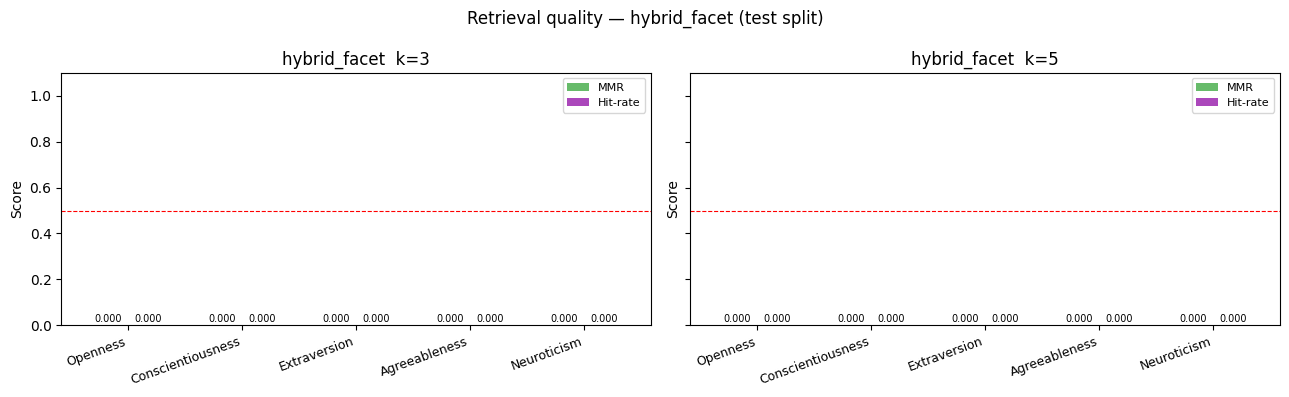

Saved: F:\std\GR\code\model_x_ocean\result\rag_ablation\hybrid_facet\rag_mmr_hr.png


In [8]:
trait_labels = [TRAIT_SHORT[tc] for tc in TRAITS]
x     = np.arange(len(trait_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, k in zip(axes, K_VALUES):
    sub = rag_summary_df[rag_summary_df["k"] == k].set_index("trait")
    mmrs = [sub.loc[TRAITS[tc], "mean_match_rate"] if TRAITS[tc] in sub.index else 0 for tc in TRAITS]
    hrs  = [sub.loc[TRAITS[tc], "hit_rate"]        if TRAITS[tc] in sub.index else 0 for tc in TRAITS]

    b1 = ax.bar(x - width/2, mmrs, width, label="MMR",      color="#4CAF50", alpha=0.85)
    b2 = ax.bar(x + width/2, hrs,  width, label="Hit-rate", color="#9C27B0", alpha=0.85)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8)
    for bar, v in zip(b1, mmrs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    for bar, v in zip(b2, hrs):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(trait_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{rag_mode}  k={k}")
    ax.legend(fontsize=8)
    ax.set_ylabel("Score")

plt.suptitle(f"Retrieval quality — {rag_mode} (test split)", fontsize=12)
plt.tight_layout()
plot_path = os.path.join(rag_metrics_dir, "rag_mmr_hr.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Step 9 — LaTeX rows for thesis tables

In [9]:
sep = "=" * 72
print(sep)
print(f"  RAG ABLATION SUMMARY  |  mode={rag_mode}")
print(sep)

# ── tab:retrieval-ablation ────────────────────────────────────────────────────
for k in K_VALUES:
    sub = rag_summary_df[rag_summary_df["k"] == k].set_index("trait")
    print(f"\n[tab:retrieval-ablation  k={k}]")
    cells = " & ".join(
        f"{sub.loc[TRAITS[tc],'mean_match_rate']:.4f}/{sub.loc[TRAITS[tc],'hit_rate']:.4f}"
        if TRAITS[tc] in sub.index else "?/?"
        for tc in TRAITS
    )
    print(f"  {rag_mode} & {k} & {cells} \\\\")

# ── tab:classification (macro-F1 per trait) ───────────────────────────────────
print(f"\n[tab:classification  rag_mode={rag_mode}]")
row_cells = " & ".join(
    f"{eval_df.loc[eval_df['trait'] == TRAIT_SHORT[tc], 'macro_f1'].values[0]:.4f}"
    if TRAIT_SHORT[tc] in eval_df["trait"].values else "?"
    for tc in TRAITS
)
avg_f1 = eval_df["macro_f1"].mean()
print(f"  {rag_mode} & {row_cells} & {avg_f1:.4f} \\\\")

print(f"\n{sep}")

  RAG ABLATION SUMMARY  |  mode=hybrid_facet

[tab:retrieval-ablation  k=3]
  hybrid_facet & 3 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 \\

[tab:retrieval-ablation  k=5]
  hybrid_facet & 5 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 & 0.0000/0.0000 \\

[tab:classification  rag_mode=hybrid_facet]


NameError: name 'eval_df' is not defined

## Step 10 — Cleanup

Restore the original `FeatureRAGRetriever` so subsequent cells aren't affected.

In [ ]:
_retriever_mod.FeatureRAGRetriever = _OriginalRetriever
print("[adapter] Original FeatureRAGRetriever restored.")